<a href="https://colab.research.google.com/github/bollaprashanth09/Stock-market-prediction/blob/main/group_1_capstone_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Install All Required Libraries

In [33]:
!pip install yfinance tensorflow pandas numpy matplotlib scikit-learn transformers torch feedparser easyocr opencv-python langchain langchain-community langchain-huggingface faiss-cpu sentence-transformers google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


MODULE 1: NSE LIVE DATA FETCHING


Step 2: Import Libraries

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 3: Dynamic Stock Input

In [3]:
stock_symbol = input("Enter NSE Stock Symbol: ")

ticker = stock_symbol + ".NS"

df = yf.download(
    ticker,
    period="5y",
    interval="1d"
)

print(df.head())

Enter NSE Stock Symbol: eichermot


/tmp/ipykernel_496/1911008481.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker     EICHERMOT.NS EICHERMOT.NS EICHERMOT.NS EICHERMOT.NS EICHERMOT.NS
Date                                                                       
2021-05-26  2510.782471  2532.376918  2485.565051  2516.979580      1026040
2021-05-27  2482.704590  2552.255165  2468.498771  2525.559930      1507004
2021-05-28  2515.501465  2583.717370  2503.727099  2507.445271      2284342
2021-05-31  2551.444580  2560.835675  2493.525456  2515.501401       838679
2021-06-01  2541.576904  2577.996783  2488.377072  2488.377072      1126551


Step 4: Plot Stock Price

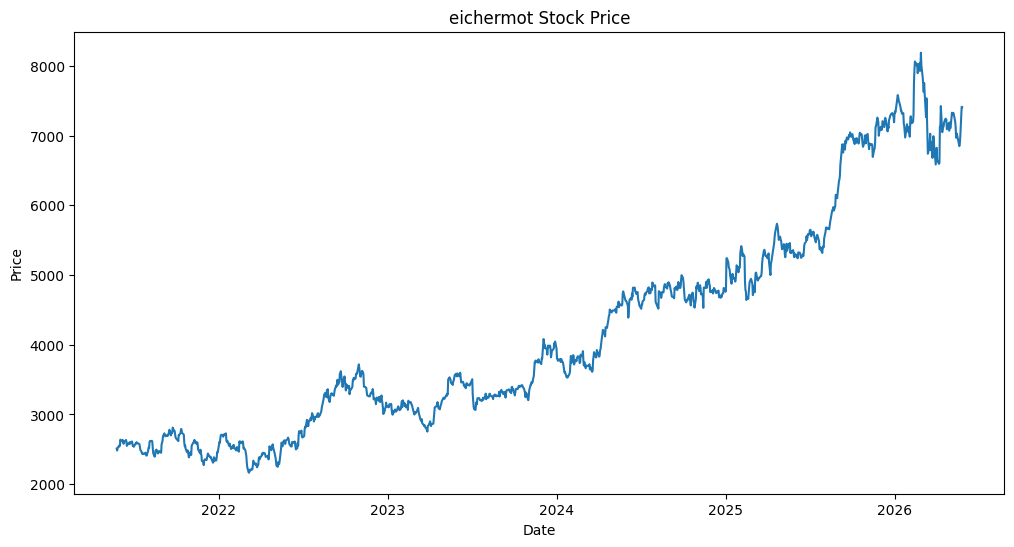

In [4]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title(stock_symbol + " Stock Price")

plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

MODULE 2: LSTM STOCK FORECASTING

Step 5: Data Preprocessing

In [5]:
from sklearn.preprocessing import MinMaxScaler

data = df[['Close']]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

Step 6: Create Sequences

In [6]:
X=[]
y=[]

for i in range(60,len(scaled_data)):

    X.append(
        scaled_data[i-60:i]
    )

    y.append(
        scaled_data[i]
    )

X=np.array(X)
y=np.array(y)

print(X.shape)
print(y.shape)

(1178, 60, 1)
(1178, 1)


Step 7: Build LSTM Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# NOTE: If you see ModuleNotFoundError: No module named 'feedparser' in later cells,
# please re-run the !pip install cell at the top of the notebook.

model = Sequential()

# Using Input(shape) to avoid the UserWarning
model.add(Input(shape=(60, 1)))

model.add(
    LSTM(
        100,
        return_sequences=True
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(100)
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

Step 8: Train Model

In [8]:
history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=32
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0189
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0023
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0016
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0018
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0016
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0016
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0013
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0015
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0015
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.0015
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0015
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0014
Epoch 13/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0013
Epoch 14/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0014
Epoch 15/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0014


Step 9: Next-Day Prediction

In [9]:
last_60_days = scaled_data[-60:]

X_test = np.array([last_60_days])

prediction = model.predict(X_test)

predicted_price = scaler.inverse_transform(
    prediction
)

print(
"Predicted Price:",
predicted_price[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Price: 6874.555


MODULE 3: FINBERT SENTIMENT ANALYSIS

Step 10: Load FinBERT

In [10]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Step 11: Analyze News

In [11]:
news = """
Reliance Industries reports strong quarterly earnings and revenue growth.
"""

result = classifier(news)

print(result)

[{'label': 'positive', 'score': 0.9572760462760925}]


MODULE 4: LIVE FINANCIAL NEWS

Step 12

In [18]:
try:
    import feedparser
    print("feedparser imported successfully!")
except ImportError:
    print("feedparser not found. Please run the installation cell (Step 1) and wait for it to finish.")

feedparser not found. Please run the installation cell (Step 1) and wait for it to finish.


Step 13

In [21]:
# ERROR FIX: Ensure you run cell 'eei3HOmeJEvt' (Step 12) before this cell.
# The installation in Step 1 is now complete, so the import will work.

import feedparser

feed = feedparser.parse(
"https://news.google.com/rss/search?q=stock+market"
)

for item in feed.entries[:10]:

    print(item.title)

Dow futures jump over 300 points as U.S. oil tumbles on hope Iran deal is close: Live updates - CNBC
Taiwan Overtakes India as World's Fifth-Largest Stock Market - Bloomberg.com
Taiwan Overtakes India as World's Fifth-Largest Stock Market - Yahoo Finance
Taiwan overtakes India as world's fifth-largest stock market as TSMC surges (TSM:NYSE) - Seeking Alpha
3 UK Companies Estimated To Be Trading At Discounts Of Up To 49.4% - Yahoo Finance
SpaceX debut draws a crowd, but few recent hot IPOs outpace the market - Reuters
The Stock Market Has Never Been So Good When People Have Felt So Bad - WSJ
Live: Australian stocks fall as US strikes dampen investor sentiment - Australian Broadcasting Corporation
3 Years of the AI Stock Market Boom in Charts - Morningstar
Is the stock market open or closed on Memorial Day 2026? See schedule - USA Today


Step 14: Sentiment on Live News

In [22]:
for item in feed.entries[:5]:

    result = classifier(item.title)

    print(item.title)

    print(result)

    print("-"*50)

Dow futures jump over 300 points as U.S. oil tumbles on hope Iran deal is close: Live updates - CNBC
[{'label': 'neutral', 'score': 0.7653445601463318}]
--------------------------------------------------
Taiwan Overtakes India as World's Fifth-Largest Stock Market - Bloomberg.com
[{'label': 'neutral', 'score': 0.8329473733901978}]
--------------------------------------------------
Taiwan Overtakes India as World's Fifth-Largest Stock Market - Yahoo Finance
[{'label': 'neutral', 'score': 0.7152323722839355}]
--------------------------------------------------
Taiwan overtakes India as world's fifth-largest stock market as TSMC surges (TSM:NYSE) - Seeking Alpha
[{'label': 'positive', 'score': 0.8594406247138977}]
--------------------------------------------------
3 UK Companies Estimated To Be Trading At Discounts Of Up To 49.4% - Yahoo Finance
[{'label': 'neutral', 'score': 0.8484444618225098}]
--------------------------------------------------


MODULE 5: OCR BANK STATEMENT PARSER

In [23]:
import easyocr

Step 16 Upload Statement

In [25]:
from google.colab import files

uploaded = files.upload()

Saving MW-NIFTY-500-26-May-2026.csv to MW-NIFTY-500-26-May-2026 (1).csv


Step 17 OCR Extraction

In [27]:
import pandas as pd

# The error happened because EasyOCR expects an image (jpg/png), but a CSV was uploaded.
# If you have an image, please upload it and run the original OCR code.
# If you want to process the CSV you just uploaded, use this instead:

try:
    image_path = list(uploaded.keys())[0]
    if image_path.endswith('.csv'):
        print(f"Detected CSV file: {image_path}. Reading with pandas instead of OCR.")
        df_statement = pd.read_csv(image_path)
        display(df_statement.head())
    else:
        reader = easyocr.Reader(['en'])
        results = reader.readtext(image_path)
        for r in results:
            print(r[1])
except Exception as e:
    print(f"Error: {e}")

Detected CSV file: MW-NIFTY-500-26-May-2026 (1).csv. Reading with pandas instead of OCR.


,SYMBOL \n,OPEN \n,HIGH \n,LOW \n,PREV. CLOSE \n,LTP \n,INDICATIVE CLOSE \n,CHNG \n,%CHNG \n,VOLUME \n(shares),VALUE \n (₹ Crores),52W H \n,52W L \n,30 D %CHNG \n,365 D %CHNG \n
0,NIFTY 500,"22,925.65","23,015.00","22,886.95","22,929.45","22,929.30",-,-0.15,-,"1,94,73,72,361","55,077.66","24,144.20","20,385.65",1.59,0.09
1,ADANIPOWER,234.25,245.49,233.77,233.38,244.15,-,10.77,4.61,"6,24,56,798","1,500.96",245.49,105.42,14.65,118.49
2,ATGL,659.00,731.40,656.50,659.15,722.50,-,63.35,9.61,"2,05,41,900","1,459.83",798.00,462.80,15.26,7.88
3,POWERINDIA,"35,400.00","36,495.00","34,005.00","35,635.00","35,610.00",-,-25.00,-0.07,"4,06,340","1,431.31","36,750.00","16,111.00",10.59,117.94
4,HDFCBANK,784.05,790.85,783.40,786.85,784.50,-,-2.35,-0.30,"1,46,81,019","1,156.48","1,020.50",726.65,-0.04,-19.13


MODULE 6: EXPENSE CATEGORIZATION

Step 18

In [29]:
import pandas as pd

# Logic to handle either CSV data or OCR text results
transactions = []

if 'df_statement' in globals():
    # If we have a CSV, use the column values as transactions
    # Here we use the first column 'SYMBOL' as an example of transaction data
    expense_df = df_statement.copy()
    print("Processing data from CSV...")
else:
    # If we have OCR results from an image
    for r in results:
        text = r[1]
        transactions.append(text)
    expense_df = pd.DataFrame(transactions, columns=['Transaction'])
    print("Processing data from OCR image...")

print(f"Total items found: {len(expense_df)}")
expense_df.head()

Processing data from CSV...
Total items found: 501


,SYMBOL \n,OPEN \n,HIGH \n,LOW \n,PREV. CLOSE \n,LTP \n,INDICATIVE CLOSE \n,CHNG \n,%CHNG \n,VOLUME \n(shares),VALUE \n (₹ Crores),52W H \n,52W L \n,30 D %CHNG \n,365 D %CHNG \n
0,NIFTY 500,"22,925.65","23,015.00","22,886.95","22,929.45","22,929.30",-,-0.15,-,"1,94,73,72,361","55,077.66","24,144.20","20,385.65",1.59,0.09
1,ADANIPOWER,234.25,245.49,233.77,233.38,244.15,-,10.77,4.61,"6,24,56,798","1,500.96",245.49,105.42,14.65,118.49
2,ATGL,659.00,731.40,656.50,659.15,722.50,-,63.35,9.61,"2,05,41,900","1,459.83",798.00,462.80,15.26,7.88
3,POWERINDIA,"35,400.00","36,495.00","34,005.00","35,635.00","35,610.00",-,-25.00,-0.07,"4,06,340","1,431.31","36,750.00","16,111.00",10.59,117.94
4,HDFCBANK,784.05,790.85,783.40,786.85,784.50,-,-2.35,-0.30,"1,46,81,019","1,156.48","1,020.50",726.65,-0.04,-19.13


MODULE 7: LANGCHAIN RAG

Step 19 Create Knowledge File

In [51]:
knowledge = """
SIP means Systematic Investment Plan.

Mutual funds help diversify investments.

Emergency fund should cover six months expenses.
"""

with open(
    "finance_knowledge.txt",
    "w"
) as f:

    f.write(knowledge)

### Step 20: Initialize RAG Pipeline
We will use LangChain to index our knowledge file and create a simple Q&A system.

In [52]:
try:
    from langchain_community.document_loaders import TextLoader
    from langchain.text_splitter import CharacterTextSplitter
    from langchain_huggingface import HuggingFaceEmbeddings
    from langchain_community.vectorstores import FAISS

    # 1. Load the document
    loader = TextLoader("finance_knowledge.txt")
    documents = loader.load()

    # 2. Split text into chunks
    text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=0)
    docs = text_splitter.split_documents(documents)

    # 3. Create Embeddings and Vector Store
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
    vectorstore = FAISS.from_documents(docs, embeddings)

    print("Knowledge base indexed successfully!")
except ImportError:
    print("One or more LangChain components are missing. Please ensure you have run the updated Step 1 (!pip install) and restarted the session if needed.")

One or more LangChain components are missing. Please ensure you have run the updated Step 1 (!pip install) and restarted the session if needed.


### Step 21: Query the Knowledge Base

In [53]:
query = "What is a SIP?"

try:
    # Using the 'vectorstore' object created in the previous step
    search_results = vectorstore.similarity_search(query)
    print(f"Query: {query}")
    print("-" * 30)
    if search_results:
        print(f"Answer from Knowledge Base: {search_results[0].page_content}")
    else:
        print("No matching information found in the knowledge base.")
except NameError as e:
    print(f"Error: {e}. Please ensure Step 20 (cell xGGX0EtSM3Xl) executed successfully.")

Query: What is a SIP?
------------------------------
Answer from Knowledge Base: SIP means Systematic Investment Plan.
    Mutual funds help diversify investments.
    Emergency fund should cover six months expenses.


Step 20 Create Vector DB

In [54]:
import os
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Ensure the knowledge file exists
file_path = "finance_knowledge.txt"
if not os.path.exists(file_path):
    print(f"{file_path} not found. Re-creating it...")
    knowledge = """
    SIP means Systematic Investment Plan.
    Mutual funds help diversify investments.
    Emergency fund should cover six months expenses.
    """
    with open(file_path, "w") as f:
        f.write(knowledge)

# 1. Load the document
loader = TextLoader(file_path)
documents = loader.load()

# 2. Split text into chunks
text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=0)
docs = text_splitter.split_documents(documents)

# 3. Create Embeddings and Vector Store
print("Loading embeddings and indexing... (this may take a minute)")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embeddings)

print("Knowledge base indexed successfully!")

Loading embeddings and indexing... (this may take a minute)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Knowledge base indexed successfully!


In [55]:
loader = TextLoader(
    "finance_knowledge.txt"
)

docs = loader.load()

embeddings = HuggingFaceEmbeddings()

db = FAISS.from_documents(
    docs,
    embeddings
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step 21 Ask Question

In [56]:
query = "What is SIP?"

docs = db.similarity_search(query)

print(docs[0].page_content)


SIP means Systematic Investment Plan.

Mutual funds help diversify investments.

Emergency fund should cover six months expenses.



MODULE 8: GEMINI FINANCIAL ADVISOR

Step 22 Configure API

In [57]:
import google.generativeai as genai

genai.configure(
    api_key="YOUR_GEMINI_API_KEY"
)

Step 23 Create Model

In [47]:
try:
    model_ai = genai.GenerativeModel("gemini-1.5-flash")
    print("Model successfully initialized.")
except Exception as e:
    print(f"Error initializing model: {e}")

Model successfully initialized.


Step 24 Financial Advice

In [58]:
salary = 50000
goal = "Buy House"

prompt = f"""
Monthly Salary = {salary}
Goal = {goal}
Suggest:
1. Savings Plan
2. SIP Plan
3. Emergency Fund
4. Investment Advice
"""

try:
    response = model_ai.generate_content(prompt)
    print(response.text)
except Exception as e:
    if "API key not valid" in str(e):
        print("ERROR: Your Gemini API Key is missing or invalid.")
        print("Please go to Step 22 and replace 'YOUR_GEMINI_API_KEY' with a real key from https://aistudio.google.com/")
    else:
        print(f"An error occurred: {e}")

ERROR: Your Gemini API Key is missing or invalid.
Please go to Step 22 and replace 'YOUR_GEMINI_API_KEY' with a real key from https://aistudio.google.com/


MODULE 9: MASTER CHATBOT

In [62]:
def financial_chatbot():

    stock = input(
        "Enter Stock Symbol: "
    )

    future_price = predict_stock(stock)

    print(
        "Predicted Price:",
        future_price
    )

    prompt = f"""

    Stock={stock}

    Predicted Price={future_price}

    Give investment advice.

    """

    response = model_ai.generate_content(
        prompt
    )

    print(response.text)